In [232]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [233]:
import pandas as pd

train = pd.read_csv("train_u6lujuX_CVtuZ9i.csv")
test = pd.read_csv("test_Y3wMUE5_7gLdaTN.csv")

print(train.shape)
print(test.shape)

train.head()

(614, 13)
(367, 12)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [234]:
# Data Cleaning

 # Your dataset has missing values in:

# Gender
# Married
#Dependents
#Self_Employed
#LoanAmount
# Loan_Amount_Term
# Credit_History  

train.fillna({
'Gender':train['Gender'].mode()[0],
'Married':train['Married'].mode()[0],
'Dependents':train['Dependents'].mode()[0],
'Self_Employed':train['Self_Employed'].mode()[0],
'LoanAmount':train['LoanAmount'].median(),
'Loan_Amount_Term':train['Loan_Amount_Term'].mode()[0],
'Credit_History':train['Credit_History'].mode()[0]
}, inplace=True)

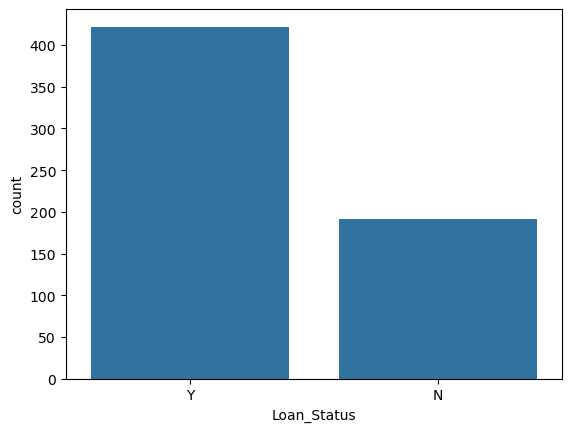

In [235]:
# Exploratory Data Analysisabs

sns.countplot(x='Loan_Status',data=train)
plt.show()

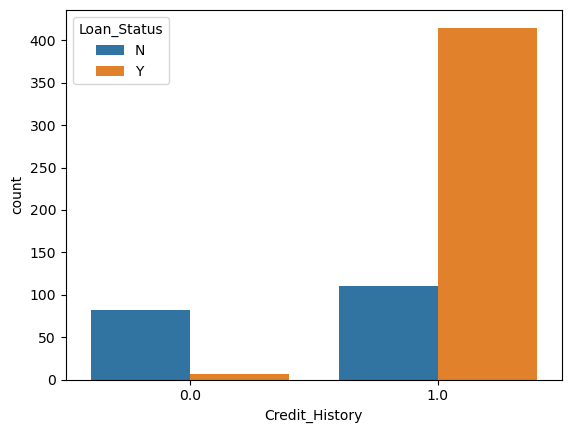

In [236]:
# Credit History vs Approval

sns.countplot(
x='Credit_History',
hue='Loan_Status',
data=train
)
plt.show()

<Axes: xlabel='ApplicantIncome', ylabel='LoanAmount'>

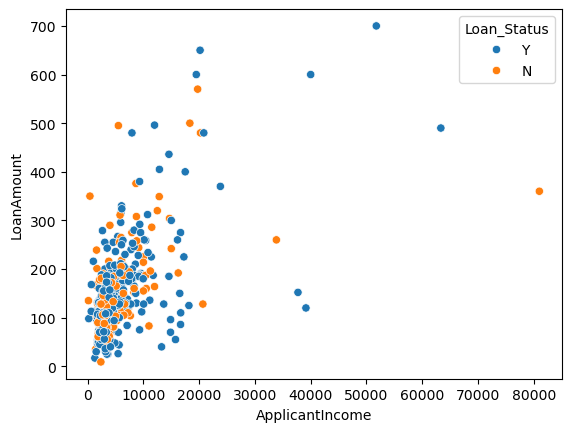

In [237]:
# Income vs Loan Amount
sns.scatterplot(
x='ApplicantIncome',
y='LoanAmount',
hue='Loan_Status',
data=train
)

In [238]:
# Feature Engineering  

train["TotalIncome"] = (
train["ApplicantIncome"] +
train["CoapplicantIncome"]
)

test["TotalIncome"]=(
test["ApplicantIncome"]+
test["CoapplicantIncome"]
)

In [239]:
# Encode Categorical Variables 
le=LabelEncoder()

cols=[
'Gender',
'Married',
'Education',
'Self_Employed',
'Property_Area',
'Loan_Status'
]

for c in cols:
    train[c]=le.fit_transform(train[c])

cat_cols=[
'Gender',
'Married',
'Education',
'Self_Employed',
'Property_Area'
]

for c in cat_cols:
    test[c]=le.fit_transform(test[c])

In [240]:
train['Dependents'] = train['Dependents'].fillna('0')
test['Dependents']  = test['Dependents'].fillna('0')

train['Dependents'] = train['Dependents'].replace(
{'3+':3}
).astype(int)

test['Dependents'] = test['Dependents'].replace(
{'3+':3}
).astype(int)

In [241]:
# Feature Selection
# Features used:
# Income
# CoIncome
# TotalIncome
# Credit_History
# Property_Area

X = train.drop(
    ['Loan_ID', 'Loan_Status'],
    axis=1
)

y = train['Loan_Status']

In [242]:
#Split Data  
X_train,X_test,y_train,y_test=train_test_split(
X,
y,
test_size=.20,
random_state=42
)

In [243]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
max_iter=8000
)

model.fit(X_train,y_train)

LogisticRegression(max_iter=8000)

In [244]:
accuracy_score(
    y_test,
    pred2 
)

0.7073170731707317

In [245]:
dt=DecisionTreeClassifier()

dt.fit(
X_train,
y_train
)

pred2=dt.predict(X_test)

In [246]:
rf=RandomForestClassifier(
n_estimators=200,
random_state=42
)

rf.fit(
X_train,
y_train
)

pred3=rf.predict(X_test)

In [247]:
print(
accuracy_score(
y_test,
pred3
))

0.7642276422764228


In [248]:
cm=confusion_matrix(
y_test,
pred3
)

print(cm)

[[18 25]
 [ 4 76]]


In [249]:
print(
classification_report(
y_test,
pred3
))

              precision    recall  f1-score   support

           0       0.82      0.42      0.55        43
           1       0.75      0.95      0.84        80

    accuracy                           0.76       123
   macro avg       0.79      0.68      0.70       123
weighted avg       0.78      0.76      0.74       123



<Axes: >

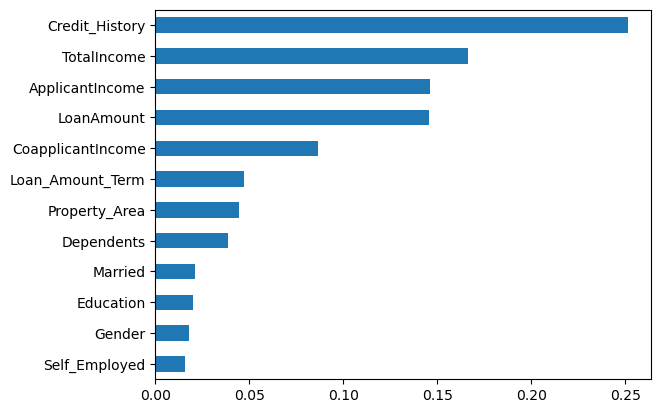

In [250]:
importance=rf.feature_importances_

pd.Series(
importance,
index=X.columns
).sort_values().plot(
kind="barh"
)

In [251]:
final_pred=rf.predict(test.drop(
'Loan_ID',
axis=1
))

In [252]:
final_pred=np.where(
final_pred==1,
'Y',
'N'
)

In [253]:
submission=pd.DataFrame({
'Loan_ID':test['Loan_ID'],
'Loan_Status':final_pred
})

submission.to_csv(
"submission.csv",
index=False
)

In [254]:
train.to_excel(
"loan_bi_dataset.xlsx",
index=False
)

In [255]:
import pickle

pickle.dump(model, open("loan_model.pkl", "wb"))

In [256]:
X = train.drop(['Loan_ID', 'Loan_Status'], axis=1)

y = train['Loan_Status']

In [257]:
X.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'TotalIncome'],
      dtype='object')

In [258]:
X = train.drop(['Loan_ID', 'Loan_Status'], axis=1)

y = train['Loan_Status']